# EDA - Datos Procesados con Sentimiento

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)


In [36]:
jsonl_path = '../data/procesada/reddit_unified_2025_with_sentiment_reclassified_025.jsonl'

records = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            if 'created_at' in data:
                data['created_at'] = pd.to_datetime(data['created_at'])
            records.append(data)
        except Exception as e:
            print(f"Error: {e}")
            continue

df = pd.DataFrame(records)
print(f"Registros cargados: {len(df):,}")
print(f"\nForma del DataFrame: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
df.head()


Registros cargados: 19,391

Forma del DataFrame: (19391, 24)

Columnas: ['id', 'source', 'source_id', 'text', 'created_at', 'title', 'author', 'url', 'subreddit', 'medium', 'score', 'num_comments', 'sentiment_label', 'tags', 'cleaned_text', 'text_length', 'keyword_count', 'lang', 'metadata', 'predicted_sentiment', 'sentiment_confidence', 'sentiment_probs', 'sentiment_model', 'sentiment_analyzed_at']


,id,source,source_id,text,created_at,title,author,url,subreddit,medium,score,num_comments,sentiment_label,tags,cleaned_text,text_length,keyword_count,lang,metadata,predicted_sentiment,sentiment_confidence,sentiment_probs,sentiment_model,sentiment_analyzed_at
0,reddit_0,reddit,0,¿El S&P 500 a largo plazo sigue valiendo la pe...,2025-01-05 00:03:17,None,None,None,None,None,None,None,None,None,None,461,None,None,None,NEG,0.606551,"{'POS': 0.010789872147142887, 'NEG': 0.6065511...",pysentimiento-robertuito,2025-11-19T00:03:21.780774
1,reddit_1,reddit,1,"Claro, si quiero ver algo a más corto plazo (1...",2025-01-05 00:09:12,None,None,None,None,None,None,None,None,None,None,137,None,None,None,NEU,0.579798,"{'POS': 0.009805828332901001, 'NEG': 0.4103964...",pysentimiento-robertuito,2025-11-19T00:03:21.780774
2,reddit_2,reddit,2,Por la apreciación del peso (a.k.a. bajas del ...,2025-01-05 00:11:17,None,None,None,None,None,None,None,None,None,None,245,None,None,None,NEU,0.595070,"{'POS': 0.026289498433470726, 'NEG': 0.3786400...",pysentimiento-robertuito,2025-11-19T00:03:21.780774
3,reddit_3,reddit,3,Yo dejaría ahi un fondo en dólares que no pien...,2025-01-05 00:12:00,None,None,None,None,None,None,None,None,None,None,170,None,None,None,NEU,0.872941,"{'POS': 0.038096655160188675, 'NEG': 0.0889626...",pysentimiento-robertuito,2025-11-19T00:03:21.780774
4,reddit_4,reddit,4,Todavia soy muy noob en esto pero merval a cor...,2025-01-05 00:12:16,None,None,None,None,None,None,None,None,None,None,270,None,None,None,POS,0.373021,"{'POS': 0.3730212152004242, 'NEG': 0.025877699...",pysentimiento-robertuito,2025-11-19T00:03:21.780774


In [37]:
print("="*60)
print("ANÁLISIS DE SENTIMIENTO Y BALANCE DE CLASES")
print("="*60)

if 'predicted_sentiment' in df.columns:
    sentiment_counts = df['predicted_sentiment'].value_counts()
    total = len(df)
    
    print(f"\nDistribución de sentimientos:")
    for sentiment in ['POS', 'NEG', 'NEU']:
        count = sentiment_counts.get(sentiment, 0)
        pct = (count / total) * 100
        print(f"  {sentiment}: {count:,} ({pct:.2f}%)")
    
    # Análisis de balance
    print(f"\n{'='*60}")
    print("ANÁLISIS DE BALANCE")
    print("="*60)
    
    max_count = sentiment_counts.max()
    min_count = sentiment_counts.min()
    ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"Ratio mayor/menor clase: {ratio:.2f}:1")
    
    if ratio > 2:
        print("⚠️  ADVERTENCIA: Hay desbalance significativo entre clases")
        print("   Considera técnicas de balanceo para el entrenamiento")
    else:
        print("✓ Balance de clases aceptable")
    
    if 'sentiment_confidence' in df.columns:
        print(f"\nConfianza promedio: {df['sentiment_confidence'].mean():.3f}")
        print(f"Confianza mediana: {df['sentiment_confidence'].median():.3f}")
        print(f"Confianza mínima: {df['sentiment_confidence'].min():.3f}")
        print(f"Confianza máxima: {df['sentiment_confidence'].max():.3f}")
else:
    print("No se encontró columna 'predicted_sentiment'")


ANÁLISIS DE SENTIMIENTO Y BALANCE DE CLASES

Distribución de sentimientos:
  POS: 1,311 (6.76%)
  NEG: 9,149 (47.18%)
  NEU: 8,931 (46.06%)

ANÁLISIS DE BALANCE
Ratio mayor/menor clase: 6.98:1
⚠️  ADVERTENCIA: Hay desbalance significativo entre clases
   Considera técnicas de balanceo para el entrenamiento

Confianza promedio: 0.751
Confianza mediana: 0.779
Confianza mínima: 0.250
Confianza máxima: 0.988


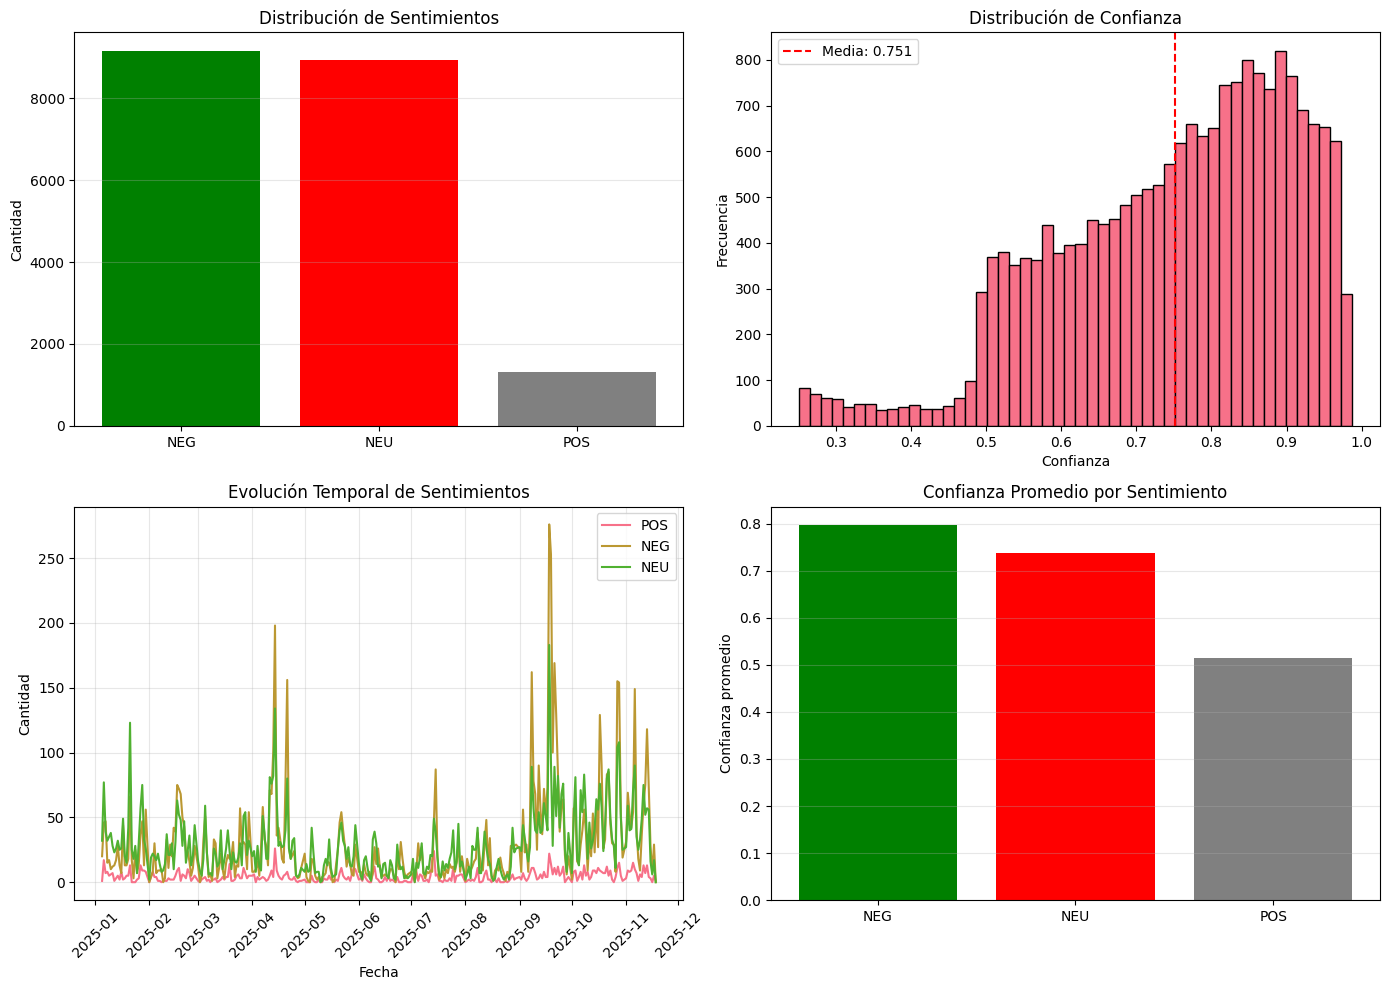

In [38]:
if 'predicted_sentiment' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Distribución de sentimientos
    sentiment_counts = df['predicted_sentiment'].value_counts()
    axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
    axes[0, 0].set_ylabel('Cantidad')
    axes[0, 0].set_title('Distribución de Sentimientos')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Distribución de confianza
    if 'sentiment_confidence' in df.columns:
        axes[0, 1].hist(df['sentiment_confidence'], bins=50, edgecolor='black')
        axes[0, 1].set_xlabel('Confianza')
        axes[0, 1].set_ylabel('Frecuencia')
        axes[0, 1].set_title('Distribución de Confianza')
        axes[0, 1].axvline(df['sentiment_confidence'].mean(), color='r', linestyle='--', 
                          label=f'Media: {df["sentiment_confidence"].mean():.3f}')
        axes[0, 1].legend()
    
    # Sentimiento por día
    df['date'] = df['created_at'].dt.date
    daily_sentiment = df.groupby(['date', 'predicted_sentiment']).size().unstack(fill_value=0)
    axes[1, 0].plot(daily_sentiment.index, daily_sentiment.get('POS', 0), label='POS', linewidth=1.5)
    axes[1, 0].plot(daily_sentiment.index, daily_sentiment.get('NEG', 0), label='NEG', linewidth=1.5)
    axes[1, 0].plot(daily_sentiment.index, daily_sentiment.get('NEU', 0), label='NEU', linewidth=1.5)
    axes[1, 0].set_xlabel('Fecha')
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].set_title('Evolución Temporal de Sentimientos')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Confianza por sentimiento
    if 'sentiment_confidence' in df.columns:
        sentiment_conf = df.groupby('predicted_sentiment')['sentiment_confidence'].mean()
        axes[1, 1].bar(sentiment_conf.index, sentiment_conf.values, color=['green', 'red', 'gray'])
        axes[1, 1].set_ylabel('Confianza promedio')
        axes[1, 1].set_title('Confianza Promedio por Sentimiento')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


In [39]:
print("="*60)
print("ANÁLISIS TEMPORAL DE SENTIMIENTO")
print("="*60)

if 'predicted_sentiment' in df.columns:
    df['date'] = df['created_at'].dt.date
    
    daily_stats = df.groupby('date').agg({
        'predicted_sentiment': lambda x: (x == 'POS').sum(),
        'text': 'count'
    }).rename(columns={'predicted_sentiment': 'positivos', 'text': 'total'})
    
    daily_stats['negativos'] = df.groupby('date')['predicted_sentiment'].apply(lambda x: (x == 'NEG').sum())
    daily_stats['neutrales'] = df.groupby('date')['predicted_sentiment'].apply(lambda x: (x == 'NEU').sum())
    
    daily_stats['ratio_pos'] = (daily_stats['positivos'] / daily_stats['total'] * 100).round(2)
    daily_stats['ratio_neg'] = (daily_stats['negativos'] / daily_stats['total'] * 100).round(2)
    daily_stats['score_sentimiento'] = ((daily_stats['positivos'] - daily_stats['negativos']) / daily_stats['total']).round(3)
    
    print(f"\nEstadísticas diarias (primeros 10 días):")
    print(daily_stats.head(10))
    
    print(f"\nEstadísticas diarias (últimos 10 días):")
    print(daily_stats.tail(10))


ANÁLISIS TEMPORAL DE SENTIMIENTO

Estadísticas diarias (primeros 10 días):
            positivos  total  negativos  neutrales  ratio_pos  ratio_neg  \
date                                                                       
2025-01-05          1     53         20         32       1.89      37.74   
2025-01-06         17    140         46         77      12.14      32.86   
2025-01-07          7     93         47         39       7.53      50.54   
2025-01-08          8     55         15         32      14.55      27.27   
2025-01-09          5     57         17         35       8.77      29.82   
2025-01-10          6     54         10         38      11.11      18.52   
2025-01-11          7     47         12         28      14.89      25.53   
2025-01-12          1     37         13         23       2.70      35.14   
2025-01-13          3     46         17         26       6.52      36.96   
2025-01-14          5     65         28         32       7.69      43.08   

            

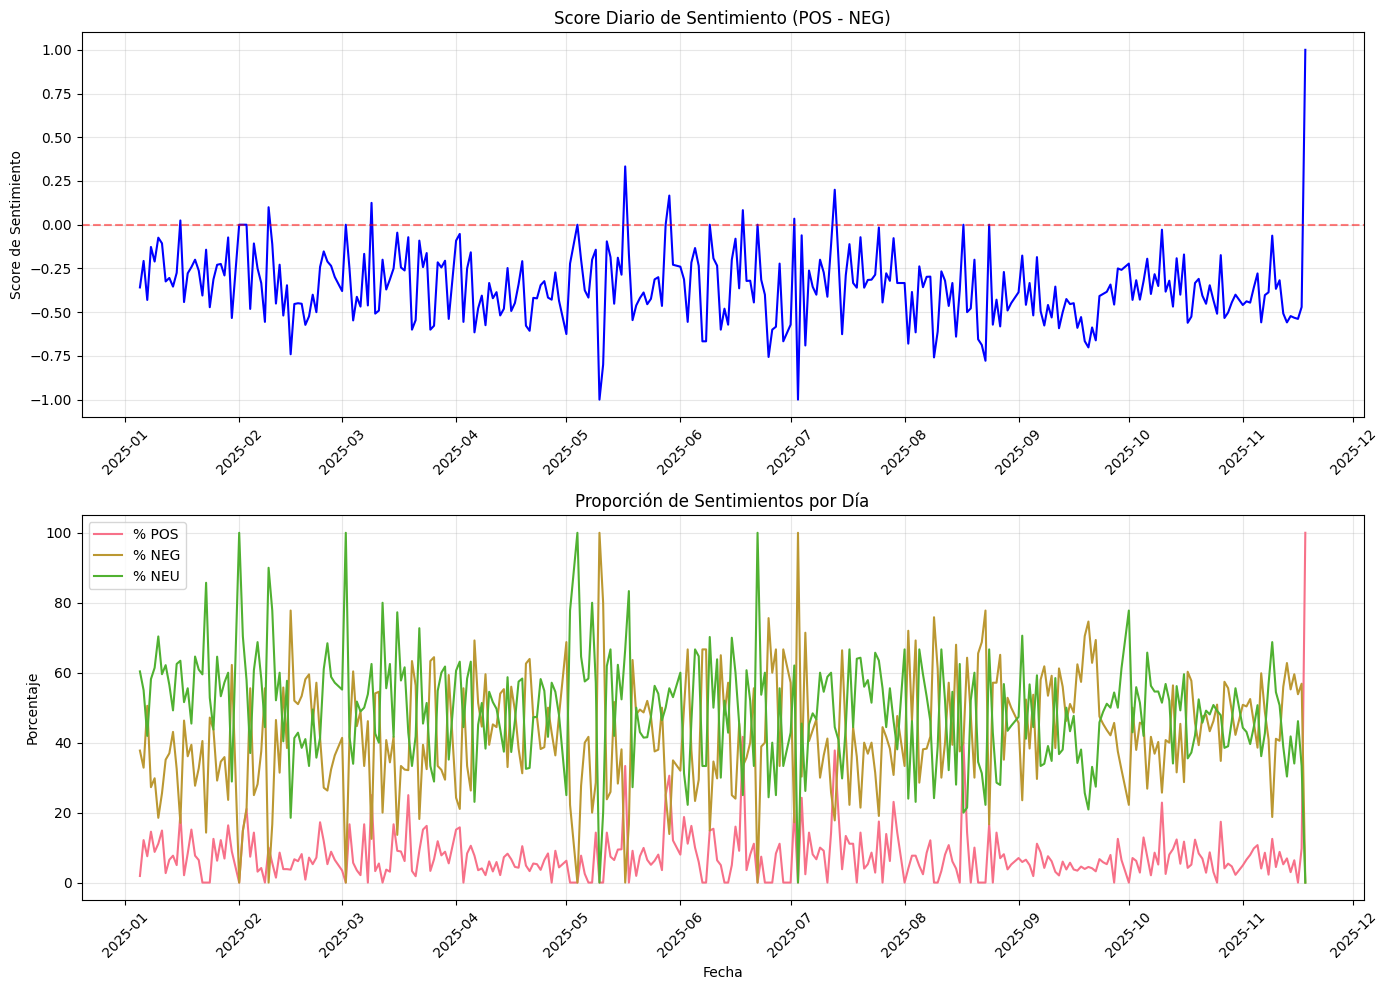

In [40]:
if 'predicted_sentiment' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Score de sentimiento diario
    daily_stats = df.groupby('date').agg({
        'predicted_sentiment': lambda x: ((x == 'POS').sum() - (x == 'NEG').sum()) / len(x)
    }).rename(columns={'predicted_sentiment': 'score'})
    
    axes[0].plot(daily_stats.index, daily_stats['score'], linewidth=1.5, color='blue')
    axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('Score de Sentimiento')
    axes[0].set_title('Score Diario de Sentimiento (POS - NEG)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Proporción de sentimientos por día
    daily_sentiment = df.groupby(['date', 'predicted_sentiment']).size().unstack(fill_value=0)
    daily_sentiment['total'] = daily_sentiment.sum(axis=1)
    daily_sentiment['pct_pos'] = (daily_sentiment.get('POS', 0) / daily_sentiment['total'] * 100)
    daily_sentiment['pct_neg'] = (daily_sentiment.get('NEG', 0) / daily_sentiment['total'] * 100)
    daily_sentiment['pct_neu'] = (daily_sentiment.get('NEU', 0) / daily_sentiment['total'] * 100)
    
    axes[1].plot(daily_sentiment.index, daily_sentiment['pct_pos'], label='% POS', linewidth=1.5)
    axes[1].plot(daily_sentiment.index, daily_sentiment['pct_neg'], label='% NEG', linewidth=1.5)
    axes[1].plot(daily_sentiment.index, daily_sentiment['pct_neu'], label='% NEU', linewidth=1.5)
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('Porcentaje')
    axes[1].set_title('Proporción de Sentimientos por Día')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [41]:
print("="*60)
print("RESUMEN FINAL")
print("="*60)

print(f"\nTotal de registros: {len(df):,}")
print(f"Registros con sentimiento: {df['predicted_sentiment'].notna().sum():,}")

if 'predicted_sentiment' in df.columns:
    sentiment_counts = df['predicted_sentiment'].value_counts()
    print(f"\nDistribución:")
    for sentiment, count in sentiment_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {sentiment}: {count:,} ({pct:.2f}%)")
    
    if 'sentiment_confidence' in df.columns:
        print(f"\nConfianza promedio: {df['sentiment_confidence'].mean():.3f}")
    
    df['date'] = df['created_at'].dt.date
    daily_sentiment = df.groupby('date')['predicted_sentiment'].apply(
        lambda x: ((x == 'POS').sum() - (x == 'NEG').sum()) / len(x)
    )
    print(f"\nScore promedio diario: {daily_sentiment.mean():.3f}")
    print(f"Día más positivo: {daily_sentiment.idxmax()} (score: {daily_sentiment.max():.3f})")
    print(f"Día más negativo: {daily_sentiment.idxmin()} (score: {daily_sentiment.min():.3f})")


RESUMEN FINAL

Total de registros: 19,391
Registros con sentimiento: 19,391

Distribución:
  NEG: 9,149 (47.18%)
  NEU: 8,931 (46.06%)
  POS: 1,311 (6.76%)

Confianza promedio: 0.751

Score promedio diario: -0.348
Día más positivo: 2025-11-18 (score: 1.000)
Día más negativo: 2025-05-10 (score: -1.000)


## Análisis Cualitativo: Visualización de Textos Etiquetados

Muestra aleatoria de textos por cada clase de sentimiento para análisis cualitativo.


In [42]:
if 'predicted_sentiment' in df.columns:
    # Función para mostrar muestras por clase
    def mostrar_muestras(df, clase, n=5):
        muestras = df[df['predicted_sentiment'] == clase].sample(min(n, len(df[df['predicted_sentiment'] == clase])))
        print(f"\n{'='*80}")
        print(f"MUESTRAS ALEATORIAS - {clase} (n={len(muestras)})")
        print(f"{'='*80}")
        for idx, row in muestras.iterrows():
            texto = str(row.get('text', ''))[:200]  # Primeros 200 caracteres
            confianza = row.get('sentiment_confidence', 0)
            fecha = row.get('created_at', '')
            print(f"\n[{idx}] Confianza: {confianza:.3f} | Fecha: {fecha}")
            print(f"Texto: {texto}...")
            print("-" * 80)
    
    # Mostrar muestras de cada clase
    for clase in ['POS', 'NEG', 'NEU']:
        if clase in df['predicted_sentiment'].values:
            mostrar_muestras(df, clase, n=5)



MUESTRAS ALEATORIAS - POS (n=5)

[19103] Confianza: 0.691 | Fecha: 2025-11-13 19:29:08
Texto: Recuerdo claramente en el 2023 cuando la inflación mensual rondaba el 30% y los precios cambiaban todos los días. TODOS LOS DIAS. Y me acuerdo que impusieron precio maximo y empezó a haber desabasteci...
--------------------------------------------------------------------------------

[11060] Confianza: 0.885 | Fecha: 2025-09-07 21:23:45
Texto: Las oportunidades de tener cash dolar  siempre las dio el peronismo. Vamos!!!  Dale que ustedes pueden!!...
--------------------------------------------------------------------------------

[17412] Confianza: 0.679 | Fecha: 2025-10-28 17:03:41
Texto: Mételo a FCI de Ualá… 

/s

Hace lo que te dijo el de arriba, muy buena estrategia...
--------------------------------------------------------------------------------

[18572] Confianza: 0.577 | Fecha: 2025-11-09 21:27:28
Texto: Ahorrar para un crédito hipotecario o alquilar para "mejorar" mi vida ahora mi

In [43]:
df_pos = df[df['predicted_sentiment'] == 'POS']
df_pos[df_pos['sentiment_confidence'] > 0.7].count()

id                       306
source                   306
source_id                306
text                     306
created_at               306
title                      0
author                     0
url                        0
subreddit                  0
medium                     0
score                      0
num_comments               0
sentiment_label            0
tags                       0
cleaned_text               0
text_length              306
keyword_count              0
lang                       0
metadata                   0
predicted_sentiment      306
sentiment_confidence     306
sentiment_probs          306
sentiment_model          306
sentiment_analyzed_at    306
date                     306
dtype: int64

In [44]:
# Crear DataFrame interactivo para explorar textos
if 'predicted_sentiment' in df.columns:
    # Filtrar columnas relevantes para visualización
    df_visual = df[['text', 'predicted_sentiment', 'sentiment_confidence', 'created_at']].copy()
    df_visual['text_length'] = df_visual['text'].str.len()
    df_visual['text_preview'] = df_visual['text'].str[:100] + '...'
    
    print("DataFrame para exploración (primeras 20 filas):")
    print("="*80)
    display(df_visual[['text_preview', 'predicted_sentiment', 'sentiment_confidence', 'created_at']].head(20))
    
    print("\nPara ver un texto completo, usa:")
    print("  df_visual.iloc[0]['text']  # Ver texto completo del primer registro")
    print("  df_visual[df_visual['predicted_sentiment'] == 'POS'].iloc[0]['text']  # Ver un POS")


DataFrame para exploración (primeras 20 filas):


,text_preview,predicted_sentiment,sentiment_confidence,created_at
0,¿El S&P 500 a largo plazo sigue valiendo la pe...,NEG,0.606551,2025-01-05 00:03:17
1,"Claro, si quiero ver algo a más corto plazo (1...",NEU,0.579798,2025-01-05 00:09:12
2,Por la apreciación del peso (a.k.a. bajas del ...,NEU,0.595070,2025-01-05 00:11:17
3,Yo dejaría ahi un fondo en dólares que no pien...,NEU,0.872941,2025-01-05 00:12:00
4,Todavia soy muy noob en esto pero merval a cor...,POS,0.373021,2025-01-05 00:12:16
5,Yo estoy en la misma. Tengo criptos pero me qu...,NEU,0.940313,2025-01-05 00:20:05
6,No es comparable el riesgo de merval con el de...,NEG,0.742903,2025-01-05 00:29:22
7,"Si tenes cuenta de cualquier banco en dolares,...",NEG,0.561541,2025-01-05 00:31:04
8,"Yo pensaba quizás apostarle más a USDC y USDT,...",NEU,0.783391,2025-01-05 00:31:56
9,"Sí, sí, entiendo, pero me esperaba un rendimie...",NEG,0.530566,2025-01-05 00:33:11



Para ver un texto completo, usa:
  df_visual.iloc[0]['text']  # Ver texto completo del primer registro
  df_visual[df_visual['predicted_sentiment'] == 'POS'].iloc[0]['text']  # Ver un POS


## Técnicas de Balanceo de Clases


In [45]:
print("="*60)
print("TÉCNICAS DE BALANCEO DE CLASES")
print("="*60)

print("""
1. CLASS WEIGHT (Recomendado para LSTM):
   - Ajustar pesos en la función de pérdida
   - Ya implementado en train_boolean_lstm.py con pos_weight
   - No requiere modificar los datos
   - Ventaja: Usa todos los datos disponibles

2. UNDERSAMPLING:
   - Reducir la clase mayoritaria al tamaño de la minoritaria
   - Ventaja: Datos balanceados
   - Desventaja: Pierdes información de la clase mayoritaria

3. OVERSAMPLING:
   - Duplicar muestras de la clase minoritaria
   - Ventaja: No pierdes datos
   - Desventaja: Puede causar overfitting

4. SMOTE (Synthetic Minority Oversampling):
   - Crear muestras sintéticas de la clase minoritaria
   - Requiere: pip install imbalanced-learn
   - Desventaja: Funciona mejor con features numéricas

5. COMBINACIÓN (Undersampling + Oversampling):
   - Balancear ambas direcciones
   - Más complejo pero efectivo

RECOMENDACIÓN PARA ESTE PROYECTO:
- Usar CLASS WEIGHT en el entrenamiento (ya implementado)
- Si el desbalance es muy extremo (>10:1), considerar undersampling aleatorio
""")

# Mostrar código de ejemplo
print("\n" + "="*60)
print("EJEMPLO: Undersampling Simple")
print("="*60)
print("""
from sklearn.utils import resample

# Obtener la clase minoritaria
min_class = df['predicted_sentiment'].value_counts().idxmin()
min_count = df['predicted_sentiment'].value_counts().min()

# Balancear cada clase
df_balanced = pd.DataFrame()
for clase in df['predicted_sentiment'].unique():
    clase_data = df[df['predicted_sentiment'] == clase]
    if len(clase_data) > min_count:
        # Undersample
        clase_data = resample(clase_data, n_samples=min_count, random_state=42)
    df_balanced = pd.concat([df_balanced, clase_data])

print(f"Original: {len(df)} registros")
print(f"Balanceado: {len(df_balanced)} registros")
""")


TÉCNICAS DE BALANCEO DE CLASES

1. CLASS WEIGHT (Recomendado para LSTM):
   - Ajustar pesos en la función de pérdida
   - Ya implementado en train_boolean_lstm.py con pos_weight
   - No requiere modificar los datos
   - Ventaja: Usa todos los datos disponibles

2. UNDERSAMPLING:
   - Reducir la clase mayoritaria al tamaño de la minoritaria
   - Ventaja: Datos balanceados
   - Desventaja: Pierdes información de la clase mayoritaria

3. OVERSAMPLING:
   - Duplicar muestras de la clase minoritaria
   - Ventaja: No pierdes datos
   - Desventaja: Puede causar overfitting

4. SMOTE (Synthetic Minority Oversampling):
   - Crear muestras sintéticas de la clase minoritaria
   - Requiere: pip install imbalanced-learn
   - Desventaja: Funciona mejor con features numéricas

5. COMBINACIÓN (Undersampling + Oversampling):
   - Balancear ambas direcciones
   - Más complejo pero efectivo

RECOMENDACIÓN PARA ESTE PROYECTO:
- Usar CLASS WEIGHT en el entrenamiento (ya implementado)
- Si el desbalance es 

In [46]:
# Función para aplicar balanceo (opcional - descomentar si quieres usarlo)
def balancear_datos(df, metodo='undersample', random_state=42):
    """
    Balancea las clases de sentimiento.
    
    Args:
        df: DataFrame con columna 'predicted_sentiment'
        metodo: 'undersample', 'oversample', o 'smote'
        random_state: Semilla aleatoria
    """
    from sklearn.utils import resample
    
    sentiment_counts = df['predicted_sentiment'].value_counts()
    min_count = sentiment_counts.min()
    max_count = sentiment_counts.max()
    
    print(f"Antes del balanceo:")
    print(sentiment_counts)
    print(f"Ratio: {max_count/min_count:.2f}:1")
    
    df_balanced = pd.DataFrame()
    
    if metodo == 'undersample':
        # Reducir todas las clases al tamaño de la menor
        for clase in df['predicted_sentiment'].unique():
            clase_data = df[df['predicted_sentiment'] == clase]
            if len(clase_data) > min_count:
                clase_data = resample(clase_data, n_samples=min_count, 
                                     random_state=random_state, replace=False)
            df_balanced = pd.concat([df_balanced, clase_data])
    
    elif metodo == 'oversample':
        # Aumentar todas las clases al tamaño de la mayor
        for clase in df['predicted_sentiment'].unique():
            clase_data = df[df['predicted_sentiment'] == clase]
            if len(clase_data) < max_count:
                clase_data = resample(clase_data, n_samples=max_count, 
                                     random_state=random_state, replace=True)
            df_balanced = pd.concat([df_balanced, clase_data])
    
    print(f"\nDespués del balanceo:")
    print(df_balanced['predicted_sentiment'].value_counts())
    print(f"Total registros: {len(df_balanced)} (original: {len(df)})")
    
    return df_balanced

# Descomentar para aplicar balanceo:
# df_balanced = balancear_datos(df, metodo='undersample')
# df = df_balanced  # Reemplazar df original con el balanceado
